In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data import DATA_DIR_PROCESSED

/Users/jueri/projects/conf26-generating-topics/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Topic Similarity

## Bar Plot

In [ ]:
df = pd.read_csv(
    DATA_DIR_PROCESSED / "topic-similarity-robust-topics.tsv", sep="\t"
)
df = df.drop_duplicates()
df = df[~df.duplicated(["name", "measure"])]
df["value"] = df["value"].str.replace("GPT-OSS-120B-O", "gpt-oss-120b")
df["value"] = df["value"].str.replace("GPT-OSS-120B", "gpt-oss-120b")
df["value"] = df["value"].str.replace("GPT-OSS-20B", "gpt-oss-20b")
df["value"] = df["value"].str.replace("Qwen3-Next-80B", "Qwen3-Next")
df["value"] = df["value"].str.replace("topic-", "")

df = df.pivot(index="name", columns="measure", values="value").reset_index()

In [3]:
df = df[df["model"] == "gpt-oss-120b"]

In [4]:
df["context"] = df[["nqueries", "ndocspos", "ndocsneg"]].max(axis=1)

In [ ]:
combined = df[["BertScore(combined)",  "model", "ndocsneg", "ndocspos", "nqueries", "prompt", "context"]].copy()
combined["field"] = "Topic"
combined.rename(columns={"BertScore(combined)": "BertScore"}, inplace=True)

title = df[["BertScore(title)",  "model", "ndocsneg", "ndocspos", "nqueries", "prompt", "context"]].copy()
title["field"] = "Title"
title.rename(columns={"BertScore(title)": "BertScore"}, inplace=True)


description = df[["BertScore(description)",  "model", "ndocsneg", "ndocspos", "nqueries", "prompt", "context"]].copy()
description["field"] = "Description"
description.rename(columns={"BertScore(description)": "BertScore"}, inplace=True)

narrative = df[["BertScore(narrative)",  "model", "ndocsneg", "ndocspos", "nqueries", "prompt", "context"]].copy()
narrative["field"] = "Narrative"
narrative.rename(columns={"BertScore(narrative)": "BertScore"}, inplace=True)

df = pd.concat([combined, title, description, narrative], axis=0)

In [ ]:
df["field"] = pd.Categorical(
    df["field"],
    categories=[
        "Topic",
        "Title",
        "Description",
        "Narrative"
    ],
    ordered=True,
)
df["prompt"] = pd.Categorical(
    df["prompt"],
    categories=[
        "query",
        "query-contrastive",
        "query-docs-pos",
        "query-docs-neg",
        "contrastive",
        "docs-pos",
        "docs-neg",
    ],
    ordered=True,
)
df["BERT Score"] = df["BertScore"].astype(float)

In [ ]:
df = df[
        (df["prompt"].isin(["query", "docs-pos", "docs-neg", "contrastive"])) |
        (df["prompt"] == "query-contrastive") & ((df["nqueries"] == df["ndocspos"])) |
        ((df["prompt"] == "query-docs-pos") & (df["nqueries"] == df["ndocspos"])) |
        ((df["prompt"] == "query-docs-neg") & (df["nqueries"] == df["ndocsneg"]))
    ]

In [ ]:
df = df[df["context"]=="1"]  # fix context to 1 for this plot

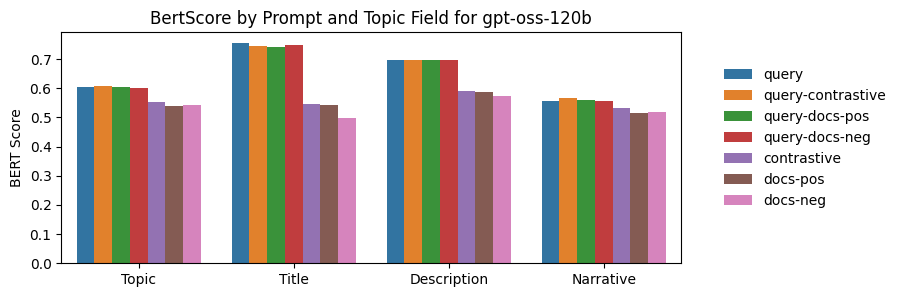

In [ ]:
plt.figure(figsize=(8, 3))

g = sns.barplot(
    data=df,
    x="field",
    y="BERT Score",
    hue="prompt",
)

g.set_xlabel("")
g.set_title("BertScore by Prompt and Topic Field for gpt-oss-120b")

plt.legend(
        bbox_to_anchor=(1.2, 0.9),
        loc="upper center",
        ncol=1,
        frameon=False,
    )
output_path = "../publication/paper/figures/topic-similarity-bar.pdf"

plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

## Len Plot

In [ ]:
df = pd.read_csv(
    DATA_DIR_PROCESSED / "topic-similarity-robust-topics.tsv", sep="\t"
)
# df = pd.read_csv(DATA_DIR_PROCESSED / "similarity-robust-topics-masked.tsv", sep="\t")
df = df.drop_duplicates()
df = df[~df.duplicated(["name", "measure"])]
df["value"] = df["value"].str.replace("GPT-OSS-120B-O", "gpt-oss-120b")
df["value"] = df["value"].str.replace("GPT-OSS-120B", "gpt-oss-120b")
df["value"] = df["value"].str.replace("GPT-OSS-20B", "gpt-oss-20b")
df["value"] = df["value"].str.replace("Qwen3-Next-80B", "Qwen3-Next")
df["value"] = df["value"].str.replace("topic-", "")

df = df.pivot(index="name", columns="measure", values="value").reset_index()

In [ ]:
df = df[df["model"] == "gpt-oss-120b"]

In [ ]:
df["context"] = df[["nqueries", "ndocspos", "ndocsneg"]].max(axis=1)

In [ ]:
df = df[["RelativeLength(combined)",  "model", "ndocsneg", "ndocspos", "nqueries", "prompt", "context"]].copy()
df["field"] = "Topic"
df.rename(columns={"RelativeLength(combined)": "RelativeLength"}, inplace=True)


In [ ]:
df["context"] = df["context"].astype(int)
df = df[df["context"] <= 5]

In [ ]:
df["prompt"] = pd.Categorical(
    df["prompt"],
    categories=[
        "query",
        "query-contrastive",
        "query-docs-pos",
        "query-docs-neg",
        "contrastive",
        "docs-pos",
        "docs-neg",
    ],
    ordered=True,
)


In [ ]:
df["Relative Length"] = df["RelativeLength"].astype(float)

In [ ]:
df = df[
        (df["prompt"].isin(["query", "docs-pos", "docs-neg", "contrastive"])) |
        (df["prompt"] == "query-contrastive") & ((df["nqueries"] == df["ndocspos"])) |
        ((df["prompt"] == "query-docs-pos") & (df["nqueries"] == df["ndocspos"])) |
        ((df["prompt"] == "query-docs-neg") & (df["nqueries"] == df["ndocsneg"]))
    ]


In [ ]:
# Increase figure size
plt.figure(figsize=(3, 2))

g = sns.lineplot(
    data=df,
    x="context",
    y="Relative Length",
    hue="prompt",
    legend=False,
)

g.set_ylim(1, 2.8)
g.set_xlabel("Number of Contexts")
g.set_title("Verbosity Across Prompts and Contexts")

# plt.legend(
#         bbox_to_anchor=(0.5, -0.15),
#         loc="upper center",
#         ncol=4,
#         frameon=False,
#     )

output_path = "../publication/paper/figures/topic-similarity-len.pdf"
plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

